# Automobile Database
---

## Objetivo
Estudo e pratica de manipulação dos dados, analise exploratoria, tratamento de dados, implementação de modelos de ML e etc

Base da kaggle: https://www.kaggle.com/datasets/sumaya23abdul/automobile-database/data

---
# 1 - Verificações Iniciais

In [34]:
#Import das libs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [35]:
#Leitura inicial da base
dados = pd.read_csv('Automobile_data.csv')

#Head da base
dados.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [36]:
#Contagem de valores nulos
dados.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [37]:
#Informações adicionais
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

- Sem valores nullos 
    - Mas na avaliação do head, verifiquei que algumas amostras estão preenchidas com ˜?˜
- Diversas colunas numericas e categoricas

In [38]:
#Tamanho do DF
dados.shape

(205, 26)

In [39]:
#Distribuição dos dados (incluindo categoricas)
dados.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
normalized-losses,205,52,?,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
make,205,22,toyota,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel-type,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num-of-doors,205,3,four,114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body-style,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drive-wheels,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine-location,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheel-base,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


# 2 - Analises Graficas (Univariada)

In [54]:
#Separar DF em colunas categoricas x numericas
categ_columns = dados.select_dtypes(include='object').columns
numeric_columns = dados.select_dtypes(include=['int64', 'float64'])

## 2.1 - BoxPlot

Um boxplot (ou gráfico de caixa e bigodes) mostra a distribuição de dados quantitativos de uma forma que facilita comparações entre variáveis ​​ou entre níveis de uma variável categórica. O gráfico de caixa mostra os quartis do conjunto de dados, enquanto os bigodes se estendem para mostrar o restante da distribuição, exceto para pontos que são determinados como "outliers" usando um método que é uma função do intervalo interquartil.

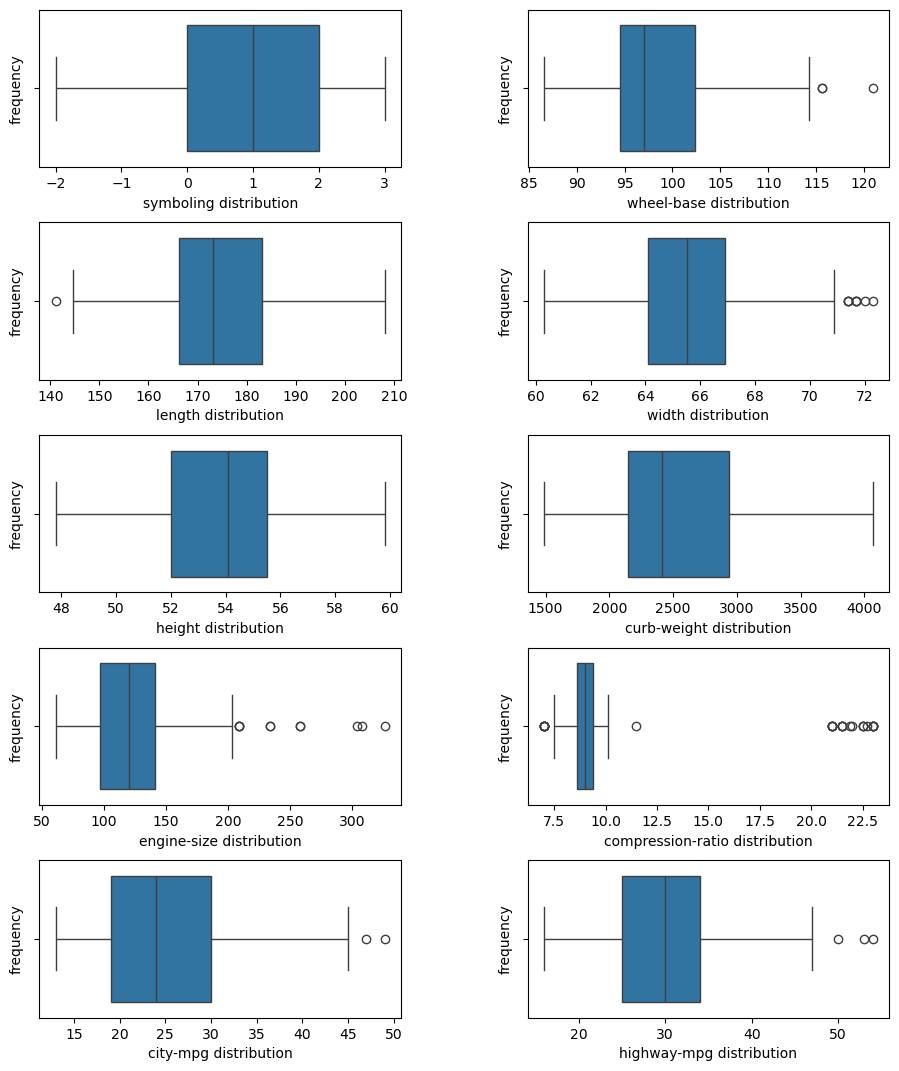

In [41]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 12))

#Grafico de BoxPlot
for i, col in enumerate(numeric_columns):
    plt.subplot(5, 2, i + 1)  # <-- aqui está a correção
    sns.boxplot(data=dados, x=col)
    plt.xlabel(col + ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

Outliers nas colunas: 
- wheel-base
- width
- engine-size
- compression-ratio
- city-mpg
- highway-mpg

## 2.2 - Histplot

Um histplot é uma ferramenta de visualização clássica que representa a distribuição de uma ou mais variáveis ​​contando o número de observações que se enquadram em compartimentos discretos.

Esta função pode normalizar a estatística calculada dentro de cada bin para estimar frequência, densidade ou massa de probabilidade, e pode adicionar uma curva suave obtida usando uma estimativa de densidade de kernel, semelhante a kdeplot().

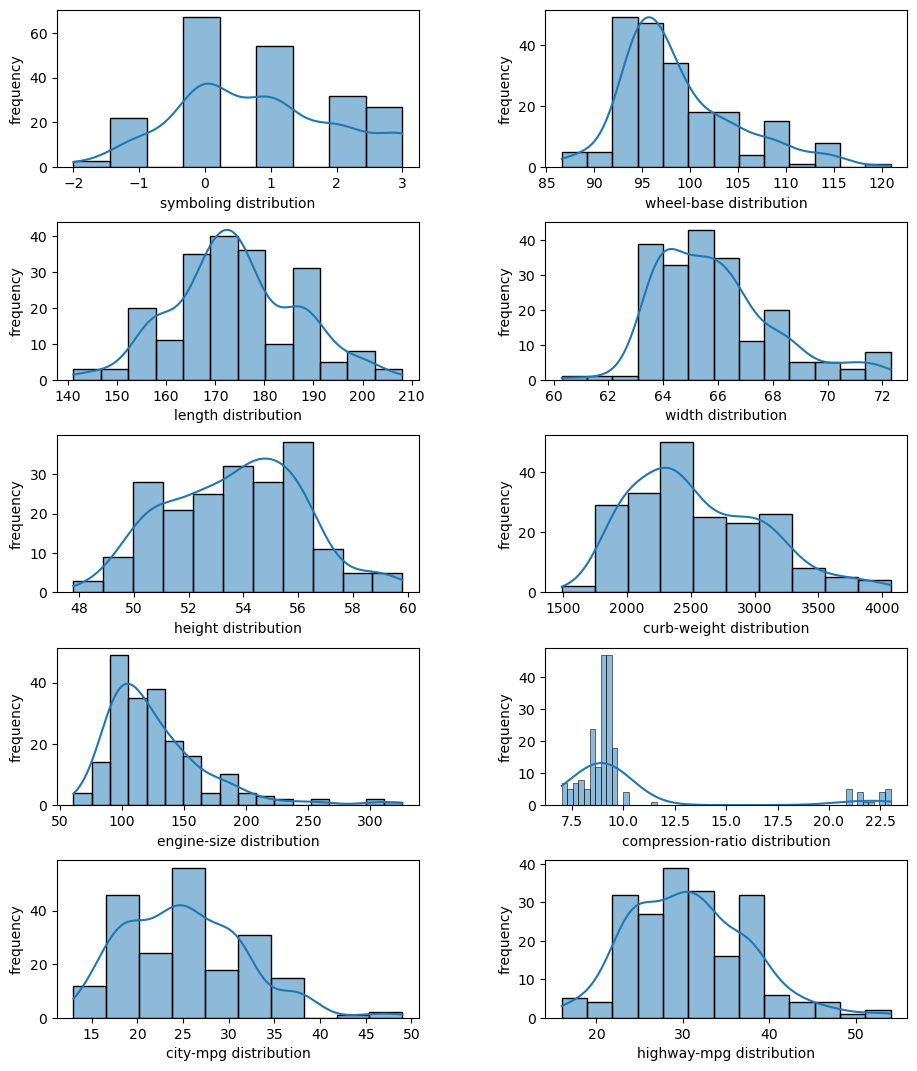

In [55]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 12))

#Grafico de BoxPlot
for i, col in enumerate(numeric_columns):
    plt.subplot(5, 2, i + 1)  # <-- aqui está a correção
    sns.histplot(data=dados, x=col, kde=True)
    plt.xlabel(col + ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

## 2.3 - Barplot

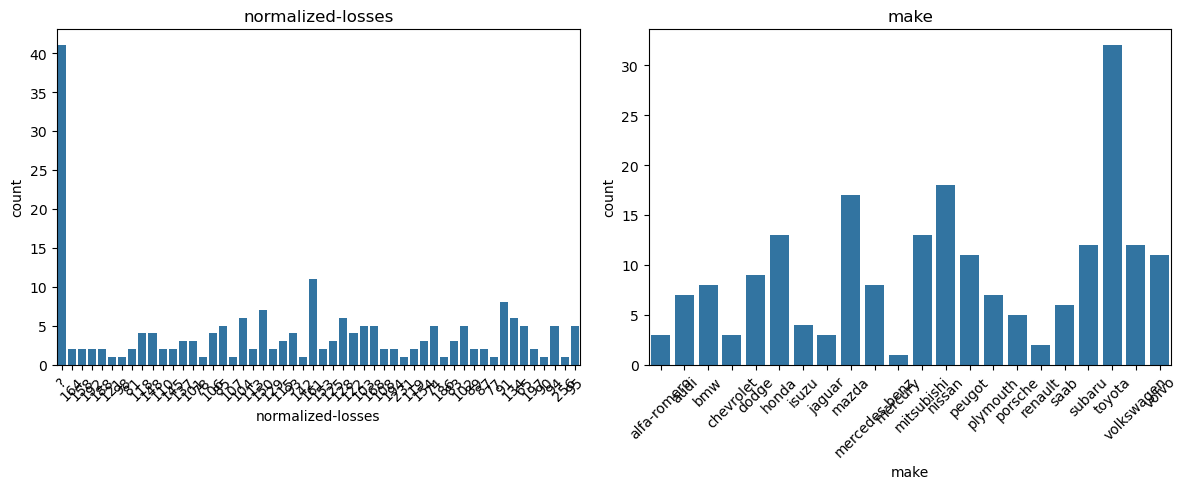

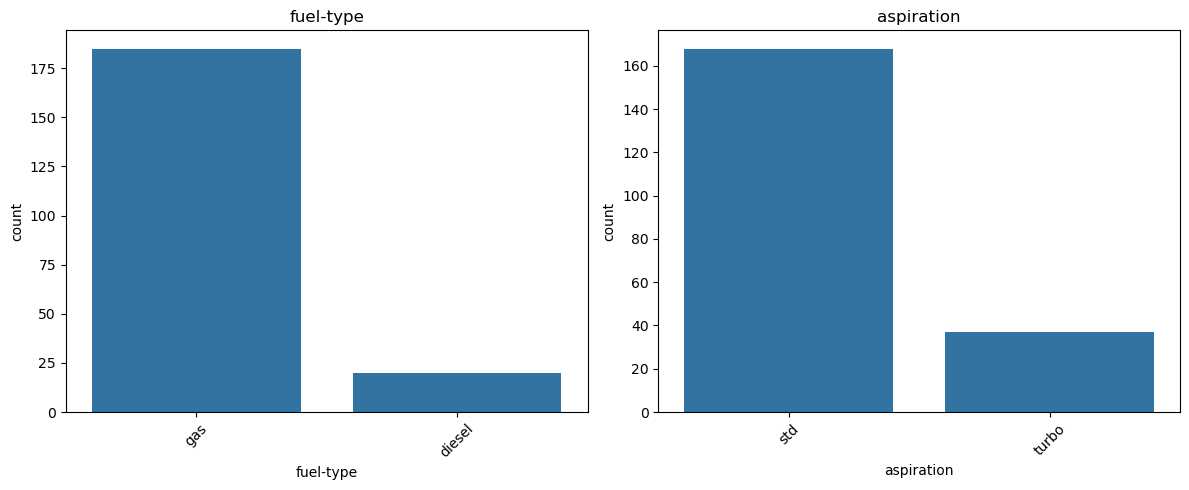

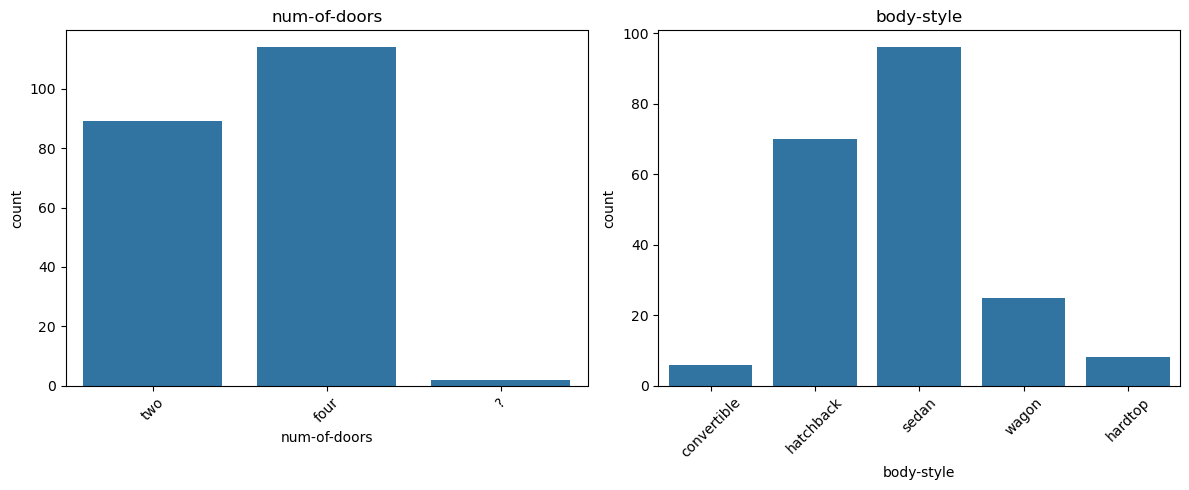

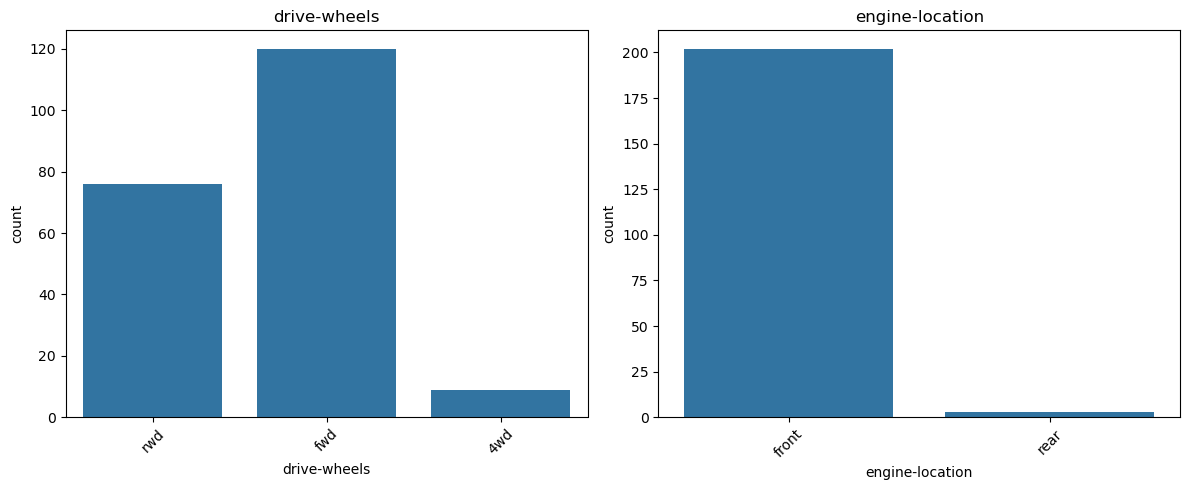

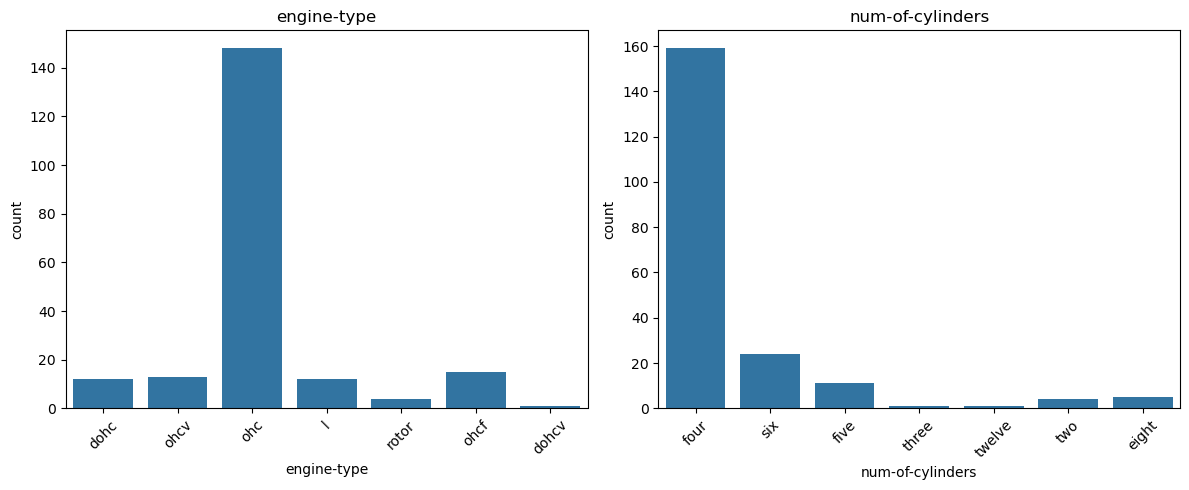

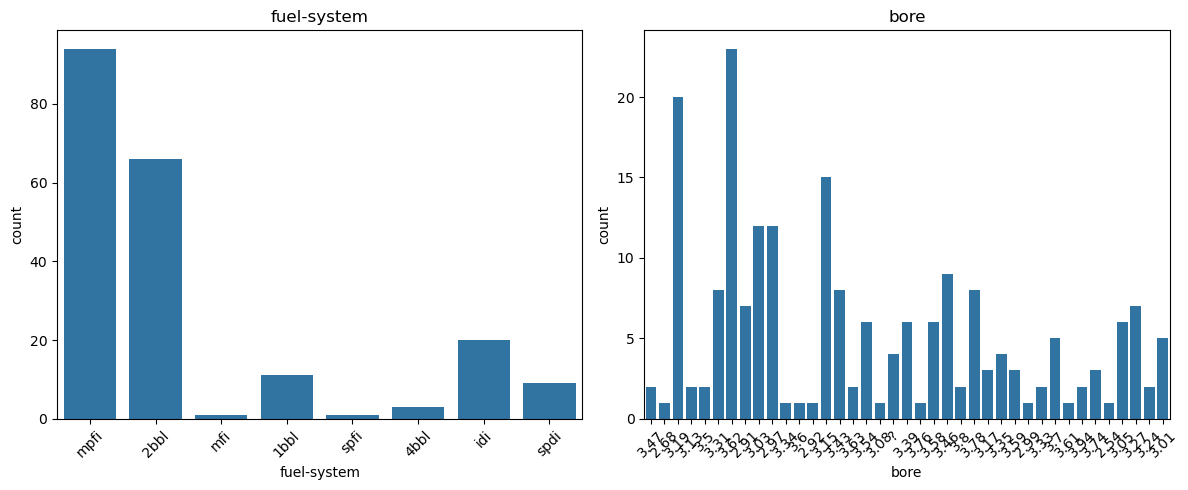

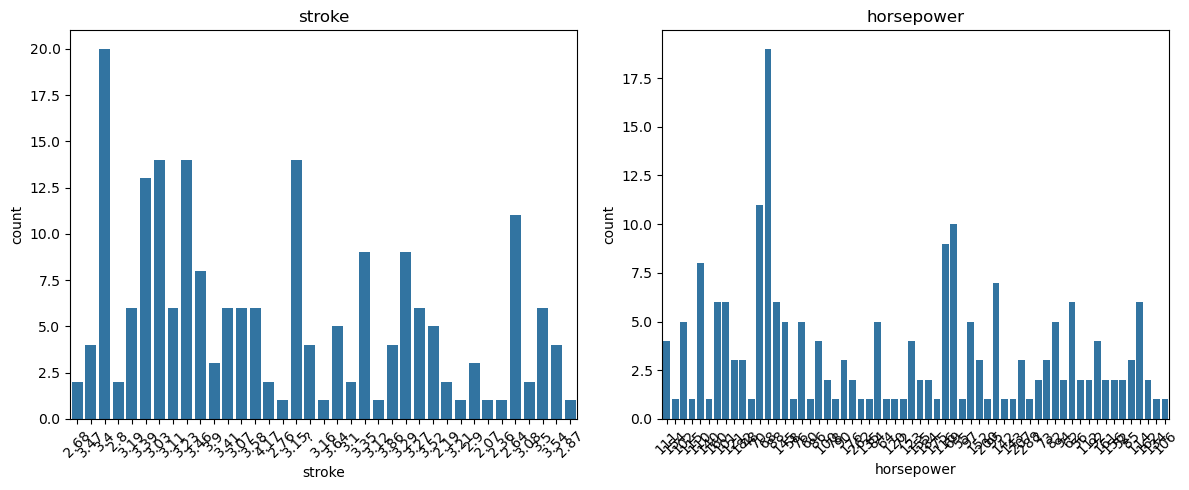

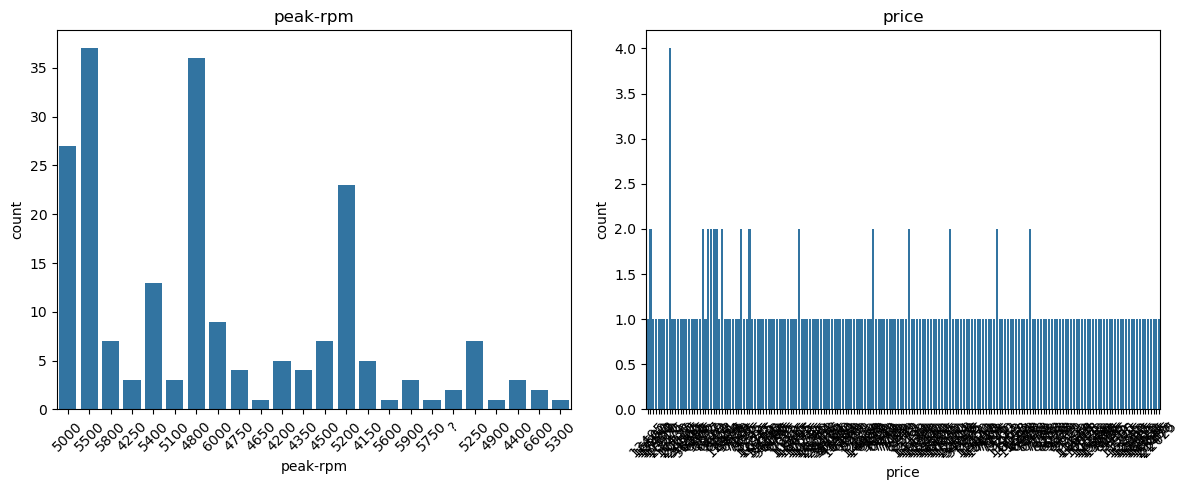

In [56]:
for i in range(0, len(categ_columns), 2):
    plt.figure(figsize=(12, 5))
    
    # Primeiro gráfico
    plt.subplot(1, 2, 1)
    col = categ_columns[i]
    sns.countplot(data=dados, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    
    # Segundo gráfico
    if i + 1 < len(categ_columns):
        plt.subplot(1, 2, 2)
        col = categ_columns[i+1]
        sns.countplot(data=dados, x=col)
        plt.title(col)
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

